# 01. Main pipeline -- cross-frequency ARI walkthrough

This notebook walks through the headline pipeline experiment end-to-end on
the focal asset `CL`, then displays the cached full-asset paper
tables for context.

The walkthrough covers the same five steps the production pipeline runs
under `python run.py pipeline`:

1. Load 5m OHLC.
2. Resample + features at 1h (representative; the pipeline does this at
   5m / 15m / 1h / 1d).
3. Fit a 2-component GMM per frequency and align labels to the 5m axis.
4. Compute the cross-frequency ARI matrix.
5. Run a small permutation null (`n_perm=100` for speed; the cached
   pipeline result uses `n_perm=500`).

Cached paper artifacts are then displayed:

| Paper artifact | Output file |
| --- | --- |
| Table 1 / A.1 (cross_freq) | `outputs/{ASSET}_cross_freq_ari.csv` |
| Table 2 (crisis shares) | `outputs/{ASSET}_tod_crisis_distribution.csv` |
| Figure 1 (CL timeline) | `outputs/CL_timeline.png` |
| Pipeline summary + p-values | `outputs/pipeline_summary.csv` |
| Tables A.5 / A.8 / A.10-A.13 | various `outputs/*_*.csv` |
| Table A.14 (out-of-sample 2022) | `outputs_2022/pipeline_summary.csv` |

**Re-run command**: `python run.py pipeline`

In [1]:
from __future__ import annotations
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

PROJECT = Path.cwd()
_nb_file = globals().get("__vsc_ipynb_file__")
if _nb_file is not None:
    PROJECT = Path(_nb_file).resolve().parent.parent
elif PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent
sys.path.insert(0, str(PROJECT))

OUT = PROJECT / "outputs"
OUT_2022 = PROJECT / "outputs_2022"
DATA = PROJECT / "data"
DATA_2022 = PROJECT / "data_2022"

pd.set_option("display.precision", 3)
pd.set_option("display.max_columns", 50)

## Step 1 -- load raw 5m OHLC for `CL`

Calls `src.data.data_ib.load_5m_ohlc` directly on `data/CL_5m.csv`. This is the same loader the pipeline uses; it parses mixed-offset DST timestamps as UTC then converts to NY local time.

In [2]:
from src.data.data_ib import load_5m_ohlc

FOCAL = "CL"
df_5m = load_5m_ohlc(DATA / f"{FOCAL}_5m.csv")
print(f"{FOCAL}_5m: {len(df_5m):,} bars, "
      f"{df_5m.index.min()} -> {df_5m.index.max()}, "
      f"{df_5m.index.normalize().nunique()} trading days")
df_5m.head()

CL_5m: 34,896 bars, 2025-11-02 18:00:00-05:00 -> 2026-05-01 16:55:00-04:00, 155 trading days


,Open,High,Low,Close,Volume
Date,,,,,
2025-11-02 18:00:00-05:00,58.36,58.43,58.10,58.29,2872.0
2025-11-02 18:05:00-05:00,58.30,58.37,58.29,58.35,669.0
2025-11-02 18:10:00-05:00,58.35,58.36,58.29,58.30,367.0
2025-11-02 18:15:00-05:00,58.30,58.33,58.26,58.33,394.0
2025-11-02 18:20:00-05:00,58.33,58.33,58.30,58.31,313.0


## Step 2 -- resample and build risk features at 1h

Resample 5m OHLC to the 1h grid via `src.core.features.resample_ohlc`, then compute the rolling-volatility risk features used by the GMM. 1h is shown as a representative example; the pipeline does the same at 5m / 15m / 1h / 1d in parallel.

In [3]:
from src.core.features import resample_ohlc, features as build_features

ohlc_1h = resample_ohlc(df_5m, "1h")
feats_1h = build_features(ohlc_1h, "1h", stem=FOCAL, window_scale=1.0)
print(f"1h OHLC bars: {len(ohlc_1h):,}; feature columns: {list(feats_1h.columns)}")
feats_1h.head()

1h OHLC bars: 3,037; feature columns: ['ret', 'vol']


,ret,vol
Date,,
2025-11-02 18:00:00-05:00,NaN,NaN
2025-11-02 19:00:00-05:00,8.574e-04,NaN
2025-11-02 20:00:00-05:00,0.000e+00,6.063e-04
2025-11-02 21:00:00-05:00,-2.403e-03,1.690e-03
2025-11-02 22:00:00-05:00,0.000e+00,1.404e-03


## Step 3 -- fit GMM regimes per frequency, align to the 5m grid

`src.core.models.fit_aligned_regimes` is the convenience wrapper used by every extended-analysis experiment: it resamples the 5m frame to each target frequency, builds features, fits a 2-component GMM on log-volatility, labels the *higher-mean* component as crisis (label=1), then forward-fills the coarse labels onto the 5m timestamp axis so the four label streams are comparable bar-by-bar.

In [4]:
from src.core.models import fit_aligned_regimes
from src.core.config import FREQS

aligned = fit_aligned_regimes(df_5m, FOCAL, FREQS)
share_rows = []
for freq, ser in aligned.items():
    s = ser.dropna()
    share_rows.append({
        "freq": freq,
        "n_bars": int(len(s)),
        "crisis_share_pct": float(100.0 * (s == 1).mean()) if len(s) else float("nan"),
    })
pd.DataFrame(share_rows).set_index("freq")

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Win

,n_bars,crisis_share_pct
freq,,
5m,34896,20.002
15m,34896,20.074
1h,34896,37.689
1d,34896,82.187


## Step 4 -- cross-frequency ARI matrix on the aligned 5m grid

`src.core.metrics.cross_freq_ari_matrix` calls `sklearn.metrics.adjusted_rand_score` on every (fa, fb) frequency pair, restricted to bars where both label streams are non-null. The off-diagonal mean is the headline `mean_offdiag_ari` paper statistic.

In [5]:
from src.core.metrics import cross_freq_ari_matrix, mean_offdiag_ari

ari_in_process = cross_freq_ari_matrix(aligned, FREQS)
print(f"mean off-diagonal ARI (in-process): {mean_offdiag_ari(ari_in_process):.4f}")
ari_in_process.round(3)

mean off-diagonal ARI (in-process): 0.2002


,5m,15m,1h,1d
5m,1.000,0.694,0.347,-0.060
15m,0.694,1.000,0.308,-0.063
1h,0.347,0.308,1.000,-0.026
1d,-0.060,-0.063,-0.026,1.000


## Step 5 -- permutation null (small sample for speed)

Block-permutation test for the mean off-diagonal ARI: shuffle the 5m label
stream in 50-bar contiguous blocks (preserves short-horizon serial
dependence), recompute the ARI matrix, and compare against the observed
statistic. Notebook uses `n_perm=100` for speed; the production pipeline
uses `n_perm=500` and the resulting p-values are stored in
`outputs/pipeline_summary.csv`.

In [6]:
from src.core.stability import block_permute_pvalue_mean_offdiag_ari

p, ci, obs = block_permute_pvalue_mean_offdiag_ari(
    aligned, FREQS, n_perm=100, seed=42, block_size=50,
)
print(f"observed mean off-diag ARI : {obs:.4f}")
print(f"block-perm null 95% CI     : ({ci[0]:.4f}, {ci[1]:.4f})")
print(f"two-sided p-value          : {p:.4f}")

observed mean off-diag ARI : 0.2002
block-perm null 95% CI     : (-0.0096, 0.0100)
two-sided p-value          : 0.0099


## Cached headline -- `Figure 1` regime timeline (CL)

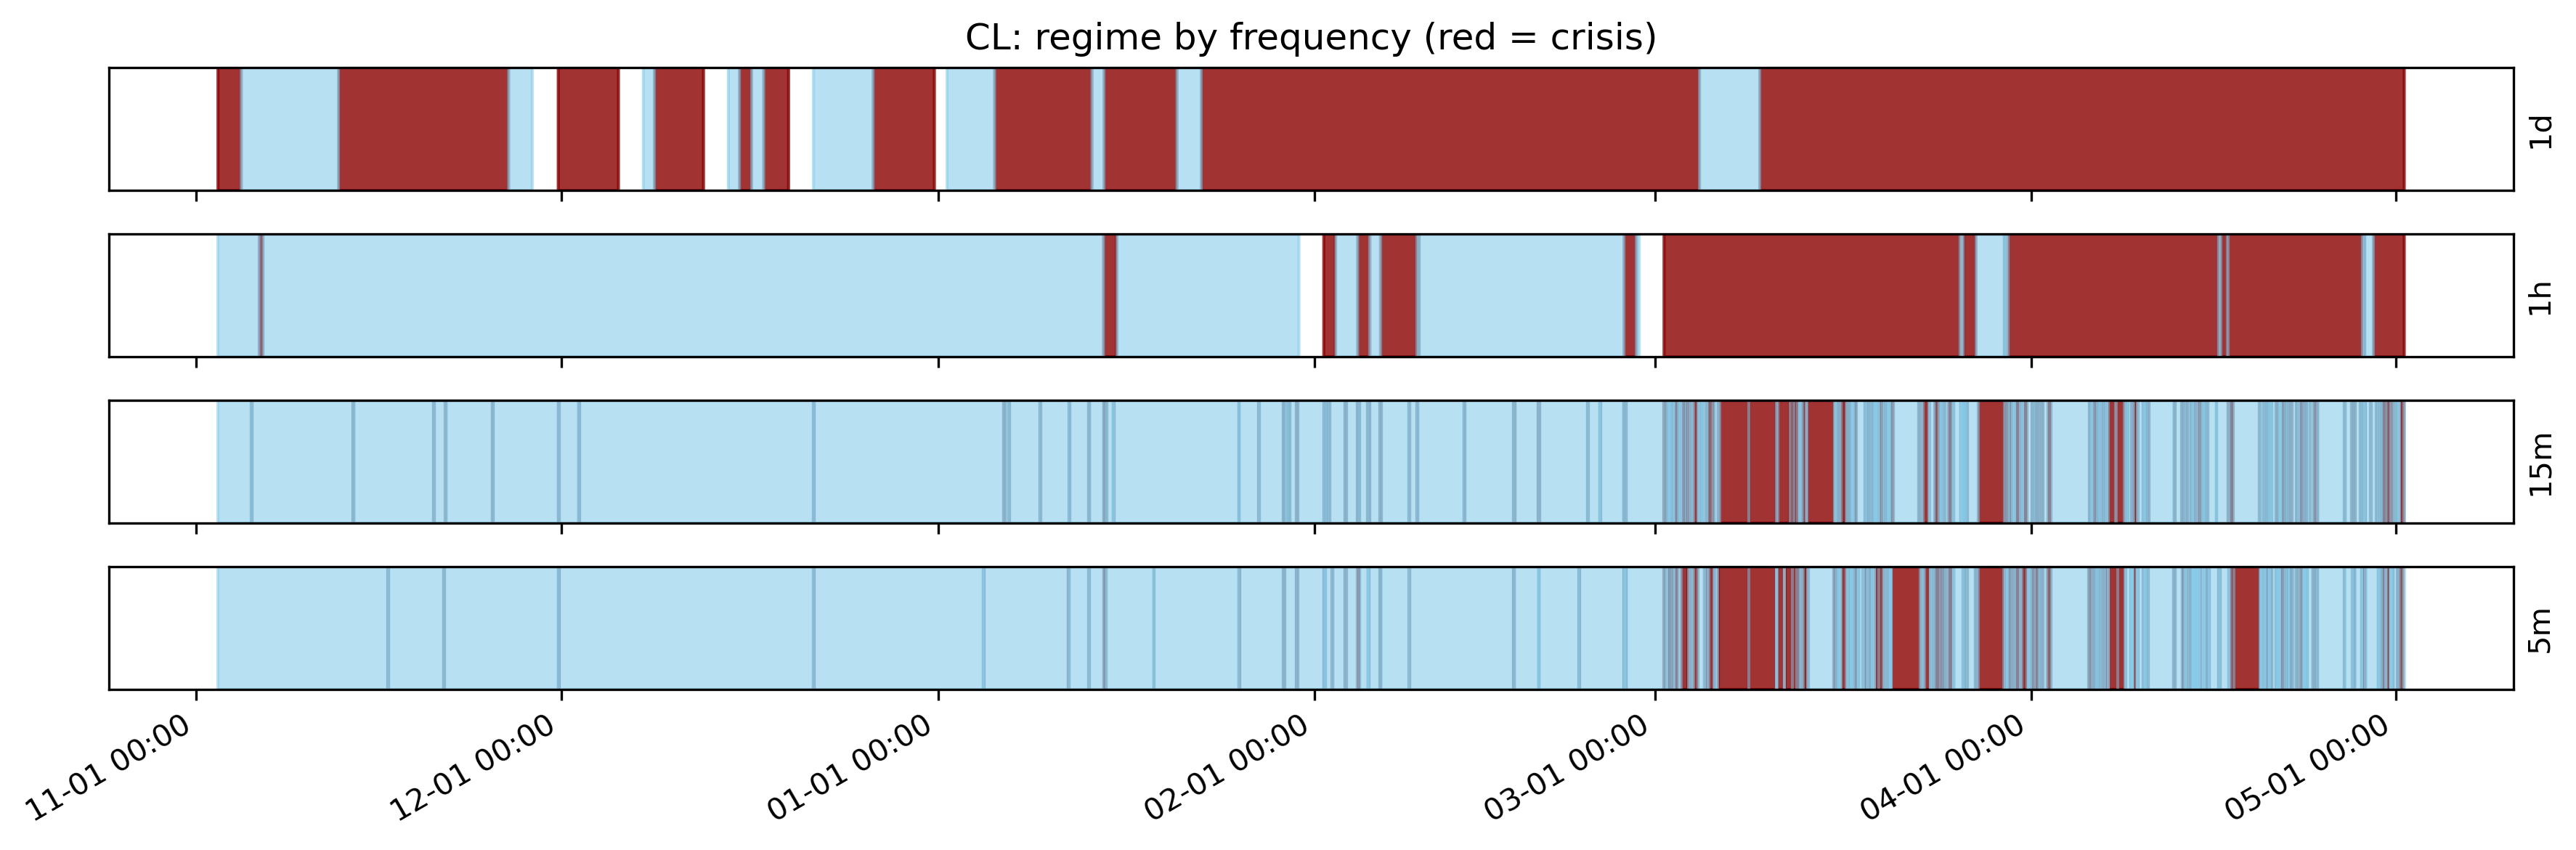

In [7]:
img = OUT / "CL_timeline.png"
display(Image(filename=str(img)) if img.exists() else Markdown(f"`{img.name}` missing"))

## Cached headline -- `pipeline_summary.csv` (mean off-diag ARI + perm p-values)

In [8]:
summary = pd.read_csv(OUT / "pipeline_summary.csv")
summary

,symbol,included,overall_mean_ari,overall_mean_ari_matrix,overall_n_valid_pairs,overall_n_total_pairs,overall_mean_ari_perm_stat,overall_mean_ari_pvalue_perm,overall_mean_ari_null_ci_low,overall_mean_ari_null_ci_high,latest_rolling_7d_mean_ari,rolling_ari_median,rolling_ari_q25,rolling_ari_q75,block_perm_pvalue,block_perm_observed_stat,block_perm_null_ci_low,block_perm_null_ci_high,expanding_mean_ari,overall_mean_ari_pvalue_perm_qvalue_bh,block_perm_pvalue_qvalue_bh
0,SPY,True,0.179,0.178,6,6,0.179,0.002,-4.327e-04,4.898e-04,0.087,0.109,0.089,0.146,0.002,0.179,-0.001,0.004,0.122,0.002,0.002
1,USDJPY,True,0.104,0.104,6,6,0.104,0.002,-1.748e-03,1.494e-03,0.276,0.076,0.058,0.115,0.002,0.104,-0.007,0.008,0.036,0.002,0.002
2,CL=F,True,0.200,0.200,6,6,0.200,0.002,-1.695e-03,1.868e-03,0.062,0.125,0.069,0.229,0.002,0.200,-0.009,0.012,0.147,0.002,0.002
3,GLD,True,0.143,0.144,6,6,0.143,0.002,-2.550e-03,2.634e-03,0.092,0.127,0.105,0.156,0.002,0.143,-0.010,0.014,0.087,0.002,0.002


## Cached `Table 1` per-asset ARI matrices

In [9]:
for asset in ['SPY', 'USDJPY', 'CL', 'GLD']:
    p = OUT / f"{asset}_cross_freq_ari.csv".format(asset=asset)
    if not p.exists():
        continue
    display(Markdown(f"### {asset}"))
    display(pd.read_csv(p, index_col=0).round(3))

### SPY

,5m,15m,1h,1d
5m,1.000,0.539,0.131,0.068
15m,0.539,1.000,0.138,0.050
1h,0.131,0.138,1.000,0.145
1d,0.068,0.050,0.145,1.000


### USDJPY

,5m,15m,1h,1d
5m,1.000,0.409,0.121,-0.018
15m,0.409,1.000,0.183,-0.026
1h,0.121,0.183,1.000,-0.046
1d,-0.018,-0.026,-0.046,1.000


### CL

,5m,15m,1h,1d
5m,1.000,0.694,0.347,-0.060
15m,0.694,1.000,0.308,-0.063
1h,0.347,0.308,1.000,-0.026
1d,-0.060,-0.063,-0.026,1.000


### GLD

,5m,15m,1h,1d
5m,1.000,0.708,0.143,-0.044
15m,0.708,1.000,0.132,-0.045
1h,0.143,0.132,1.000,-0.034
1d,-0.044,-0.045,-0.034,1.000


## Cached `Table 2` -- crisis share by resolution

In [10]:
for asset in ['SPY', 'USDJPY', 'CL', 'GLD']:
    p = OUT / f"{asset}_tod_crisis_distribution.csv"
    if not p.exists():
        continue
    display(Markdown(f"### {asset}"))
    display(pd.read_csv(p).round(3))

### SPY

,freq,hour,crisis_share,n_bars
0,5m,4,72.110,1488
1,5m,5,70.027,1488
2,5m,6,34.476,1488
3,5m,7,33.065,1488
4,5m,8,43.145,1488
...,...,...,...,...
59,1d,15,48.780,1476
60,1d,16,48.780,1476
61,1d,17,49.587,1452
62,1d,18,49.587,1452


### USDJPY

,freq,hour,crisis_share,n_bars
0,5m,0,15.885,1536
1,5m,1,19.987,1536
2,5m,2,24.284,1536
3,5m,3,27.995,1536
4,5m,4,36.328,1536
...,...,...,...,...
91,1d,19,65.354,1524
92,1d,20,65.625,1536
93,1d,21,65.625,1536
94,1d,22,65.625,1536


### CL

,freq,hour,crisis_share,n_bars
0,5m,0,6.365,1524
1,5m,1,5.249,1524
2,5m,2,8.793,1524
3,5m,3,15.026,1524
4,5m,4,19.685,1524
...,...,...,...,...
87,1d,19,81.890,1524
88,1d,20,81.890,1524
89,1d,21,81.890,1524
90,1d,22,81.890,1524


### GLD

,freq,hour,crisis_share,n_bars
0,5m,4,59.677,1488
1,5m,5,42.070,1488
2,5m,6,4.032,1488
3,5m,7,5.309,1488
4,5m,8,7.258,1488
...,...,...,...,...
59,1d,15,91.057,1476
60,1d,16,91.057,1476
61,1d,17,90.909,1452
62,1d,18,90.909,1452


## Cached `Table A.10` -- GMM fit diagnostics

In [11]:
for asset in ['SPY', 'USDJPY', 'CL', 'GLD']:
    p = OUT / f"{asset}_gmm_diagnostics.csv"
    if not p.exists():
        continue
    display(Markdown(f"### {asset}"))
    display(pd.read_csv(p).round(3))

### SPY

,freq,bic,aic,n_obs,separation,overlap,mean_0,mean_1,std_0,std_1,weight_0,weight_1
0,5m,50130.132,50089.769,23688,1.388,0.487,-8.097,-7.305,0.565,0.575,0.454,0.546
1,15m,18564.666,18529.717,8020,1.317,0.511,-6.863,-7.709,0.604,0.689,0.560,0.440
2,1h,2790.046,2761.803,2098,1.178,0.558,-6.539,-6.061,0.458,0.366,0.404,0.596
3,1d,209.696,195.595,124,1.679,0.399,-5.272,-4.614,0.410,0.371,0.528,0.472


### USDJPY

,freq,bic,aic,n_obs,separation,overlap,mean_0,mean_1,std_0,std_1,weight_0,weight_1
0,5m,49987.081,49944.570,36393,0.358,0.850,-8.501,-8.330,0.379,0.565,0.519,0.481
1,15m,19863.182,19826.112,12259,36.274,0.000,-7.953,-27.631,0.543,0.001,1.000,0.000
2,1h,2223.150,2193.008,3067,1.126,0.584,-7.196,-6.844,0.271,0.391,0.696,0.304
3,1d,245.079,229.830,156,1.163,0.559,-5.495,-5.989,0.433,0.412,0.617,0.383


### CL

,freq,bic,aic,n_obs,separation,overlap,mean_0,mean_1,std_0,std_1,weight_0,weight_1
0,5m,72824.523,72782.222,34896,30.511,0.000,-6.703,-27.631,0.687,0.001,0.997,0.003
1,15m,27574.886,27538.024,11759,27.452,0.000,-6.225,-27.631,0.781,0.001,0.997,0.003
2,1h,4976.383,4946.290,3037,3.097,0.121,-4.743,-5.741,0.321,0.323,0.383,0.617
3,1d,252.994,237.777,155,1.737,0.409,-4.018,-4.779,0.344,0.634,0.740,0.260


### GLD

,freq,bic,aic,n_obs,separation,overlap,mean_0,mean_1,std_0,std_1,weight_0,weight_1
0,5m,47123.387,47083.024,23688,1.083,0.591,-6.521,-7.192,0.897,0.467,0.281,0.719
1,15m,17629.115,17594.167,8020,0.731,0.711,-6.755,-6.244,0.549,0.914,0.652,0.348
2,1h,2751.692,2723.448,2098,1.846,0.358,-5.250,-5.902,0.418,0.302,0.400,0.600
3,1d,207.684,193.583,124,4.192,0.022,-4.245,-5.853,0.392,0.283,0.913,0.087


## Cached `Table A.11` -- expanding-window (no look-ahead) ARI

In [12]:
for asset in ['SPY', 'USDJPY', 'CL', 'GLD']:
    p = OUT / f"{asset}_expanding_cross_freq_ari.csv"
    if not p.exists():
        continue
    display(Markdown(f"### {asset}"))
    display(pd.read_csv(p, index_col=0).round(3))

### SPY

,5m,15m,1h,1d
5m,1.000,0.520,0.084,0.016
15m,0.520,1.000,0.062,0.009
1h,0.084,0.062,1.000,0.039
1d,0.016,0.009,0.039,1.000


### USDJPY

,5m,15m,1h,1d
5m,1.000,0.014,0.072,0.013
15m,0.014,1.000,0.015,0.000
1h,0.072,0.015,1.000,0.105
1d,0.013,0.000,0.105,1.000


### CL

,5m,15m,1h,1d
5m,1.000,0.743,0.080,0.002
15m,0.743,1.000,0.092,0.013
1h,0.080,0.092,1.000,-0.048
1d,0.002,0.013,-0.048,1.000


### GLD

,5m,15m,1h,1d
5m,1.000,0.375,0.066,0.0
15m,0.375,1.000,0.078,0.0
1h,0.066,0.078,1.000,0.0
1d,0.000,0.000,0.000,1.0


## Cached `Table A.8` -- robustness sweep over (K, window_scale)

In [13]:
ranges = OUT / "robustness_ranges.csv"
display(pd.read_csv(ranges).round(3) if ranges.exists() else Markdown("`robustness_ranges.csv` missing"))

,symbol,baseline_overall_mean_ari,overall_mean_ari_min,overall_mean_ari_max,baseline_latest_rolling_mean_ari,latest_rolling_mean_ari_min,latest_rolling_mean_ari_max
0,CL=F,0.200,0.184,0.530,0.062,0.062,0.295
1,GLD,0.144,0.062,0.282,0.092,0.013,0.319
2,SPY,0.178,0.085,0.195,0.087,0.046,0.240
3,USDJPY,0.104,0.036,0.253,0.276,0.077,0.415


## Cached `Table A.12` -- block-permutation sweep by block size

In [14]:
p = OUT / "block_size_sweep.csv"
display(pd.read_csv(p).round(4) if p.exists() else Markdown(f"`{p.name}` missing"))

`block_size_sweep.csv` missing

## Cached `Table A.13` -- CL roll-week vs non-roll-week

In [15]:
p = OUT / "CL_roll_week_ari.csv"
display(pd.read_csv(p).round(3) if p.exists() else Markdown(f"`{p.name}` missing"))

,roll_week_mean_ari,nonroll_week_mean_ari,roll_week_bars,nonroll_week_bars
0,0.159,0.21,8220,26676


## Cached `Table A.14` -- 2022 out-of-sample (Russia-Ukraine)

In [16]:
p = OUT_2022 / "pipeline_summary.csv"
if p.exists():
    df_2022 = pd.read_csv(p)
    if "included" in df_2022.columns:
        # Drop CL=F: no 2022 5m data available via IB CONTFUT historical service
        df_2022 = df_2022[df_2022["included"].astype(bool)].reset_index(drop=True)
    display(df_2022.round(3))
else:
    display(Markdown(f"`{p}` missing -- copy 2022 CSVs into `data_2022/` and re-run `python run.py pipeline -c config_2022.yaml`."))

,symbol,included,overall_mean_ari,overall_mean_ari_matrix,overall_n_valid_pairs,overall_n_total_pairs,overall_mean_ari_perm_stat,overall_mean_ari_pvalue_perm,overall_mean_ari_null_ci_low,overall_mean_ari_null_ci_high,latest_rolling_7d_mean_ari,rolling_ari_median,rolling_ari_q25,rolling_ari_q75,block_perm_pvalue,block_perm_observed_stat,block_perm_null_ci_low,block_perm_null_ci_high,expanding_mean_ari,overall_mean_ari_pvalue_perm_qvalue_bh,block_perm_pvalue_qvalue_bh
0,SPY,True,0.152,0.151,6.0,6.0,0.152,0.002,-0.001,0.001,0.136,0.121,0.100,0.161,0.002,0.152,-0.003,0.006,0.134,0.002,0.002
1,USDJPY,True,0.153,0.153,6.0,6.0,0.153,0.002,-0.000,0.000,0.130,0.103,0.086,0.145,0.002,0.153,-0.002,0.004,0.102,0.002,0.002
2,GLD,True,0.132,0.132,6.0,6.0,0.132,0.002,-0.002,0.002,0.086,0.110,0.091,0.130,0.002,0.132,-0.008,0.012,0.120,0.002,0.002
